# 03 — Null ve Eksik Veri Analizi

Sentetik veride bilinçli null'lar var — EDA'da **neden eksik?** sorusunu cevaplayacağız.

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
elif ROOT.name != 'eda' and (ROOT / 'eda').exists():
    ROOT = ROOT / 'eda'
sys.path.insert(0, str(ROOT))

from utils.data_loader import load_all
from utils.plots import setup_style

setup_style()
dfs = load_all()

In [2]:
# Genel null matrisi
null_rows = []
for name, df in dfs.items():
    for col in df.columns:
        n = df[col].isna().sum()
        if n:
            null_rows.append({'tablo': name, 'kolon': col, 'null_sayisi': n,
                              'oran_pct': round(100*n/len(df), 3)})
null_df = pd.DataFrame(null_rows).sort_values('null_sayisi', ascending=False)
display(null_df)

,tablo,kolon,null_sayisi,oran_pct
1,transactions,tank_no,2548,1.099
3,transactions,birim_fiyat,927,0.400
2,transactions,litre,463,0.200
13,ue1t_30min,baslangic_seviyesi_cm,414,0.300
11,inventory_30min,merkeze_gelis_tarihi,276,0.200
7,inventory_30min,urun_miktari_net,240,0.174
10,inventory_30min,sicaklik,240,0.174
12,ue1t_30min,sicaklik,240,0.174
6,deliveries,merkeze_gelis_tarihi,170,15.329
5,deliveries,sicaklik,109,9.829


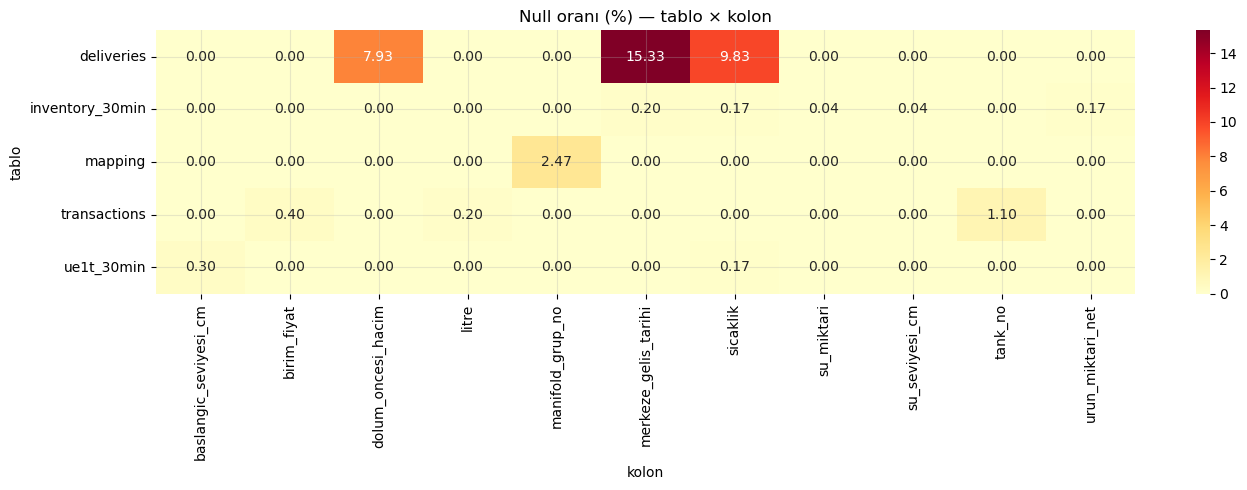

In [3]:
# Heatmap — tablo × kolon null oranı
pivot = null_df.pivot_table(index='tablo', columns='kolon', values='oran_pct', fill_value=0)
plt.figure(figsize=(14, 5))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd')
plt.title('Null oranı (%) — tablo × kolon')
plt.tight_layout()
plt.show()

In [4]:
# transactions.tank_no null — istasyon kırılımı
tx = dfs['transactions']
unmapped = tx[tx['tank_no'].isna()]
print('Unmapped satış:', len(unmapped), f'({100*len(unmapped)/len(tx):.2f}%)')
print(unmapped.groupby('istasyon_kodu').size().sort_values(ascending=False))

Unmapped satış: 2548 (1.10%)
istasyon_kodu
IST_004    418
IST_001    382
IST_002    370
IST_007    337
IST_006    330
IST_003    265
IST_008    224
IST_005    222
dtype: int64


In [5]:
# sicaklik null — tank×gün kümesi mi?
ue1t = dfs['ue1t_30min']
inv = dfs['inventory_30min']
for name, df, col in [('ue1t','ue1t_30min','sicaklik'), ('inventory','inventory_30min','sicaklik')]:
    d = dfs[name.replace('inventory','inventory_30min') if name=='inventory' else 'ue1t_30min']
    sn = d[d['sicaklik'].isna()].copy()
    if len(sn):
        sn['gun'] = sn['saat_1' if 'saat_1' in sn.columns else 'envanter_tarihi'].dt.date
        print(f'\n{name} sicaklik null: {len(sn)} satır')
        print('Tank-gün kümesi (ilk 10):')
        print(sn.groupby(['istasyon_kodu','tank_no','gun']).size().head(10))


ue1t sicaklik null: 240 satır
Tank-gün kümesi (ilk 10):
istasyon_kodu  tank_no  gun       
IST_002        1        2026-03-19    48
               4        2026-01-14    48
IST_003        1        2026-01-12    48
               3        2026-01-18    48
IST_008        2        2026-03-12    48
dtype: int64

inventory sicaklik null: 240 satır
Tank-gün kümesi (ilk 10):
istasyon_kodu  tank_no  gun       
IST_002        1        2026-03-19    47
                        2026-03-20     1
               4        2026-01-14    47
                        2026-01-15     1
IST_003        1        2026-01-12    47
                        2026-01-13     1
               3        2026-01-18    47
                        2026-01-19     1
IST_008        2        2026-03-12    47
                        2026-03-13     1
dtype: int64


In [6]:
# merkeze_gelis gecikmesi — router arızası imzası
inv = dfs['inventory_30min'].copy()
inv['gecikme_dk'] = (inv['merkeze_gelis_tarihi'] - inv['envanter_tarihi']).dt.total_seconds() / 60
print('Gecikme istatistikleri (dk):')
print(inv['gecikme_dk'].describe())

# En yüksek gecikmeli istasyon-gün
inv['tarih'] = inv['envanter_tarihi'].dt.normalize()
lag_day = inv.groupby(['istasyon_kodu','tarih'])['gecikme_dk'].median().reset_index()
top = lag_day.nlargest(5, 'gecikme_dk')
print('\nEn yüksek medyan gecikme (istasyon-gün):')
display(top)

Gecikme istatistikleri (dk):
count    137918.000000
mean          7.100661
std          35.188091
min           1.000000
25%           3.972165
50%           6.002068
75%           8.026422
max        1795.787953
Name: gecikme_dk, dtype: float64

En yüksek medyan gecikme (istasyon-gün):


,istasyon_kodu,tarih,gecikme_dk
200,IST_003,2026-01-19,993.586739
454,IST_005,2026-04-01,7.998322
636,IST_007,2026-04-01,7.671955
235,IST_003,2026-02-23,6.996523
298,IST_004,2026-01-26,6.789531


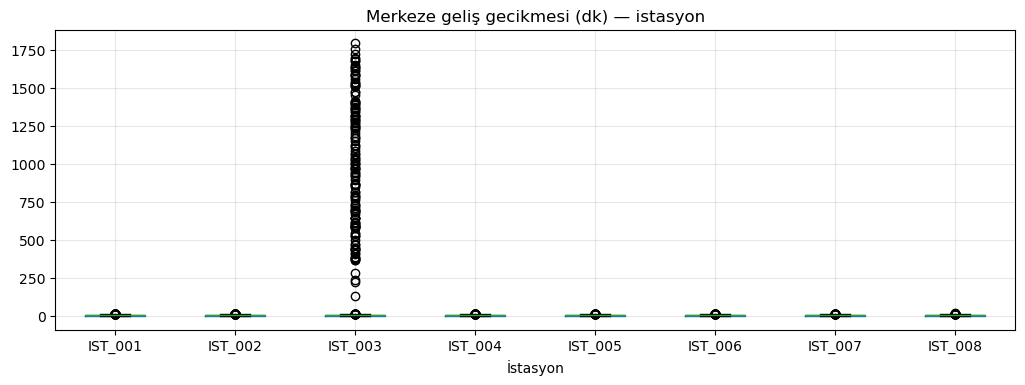

In [7]:
fig, ax = plt.subplots(figsize=(12, 4))
inv.boxplot(column='gecikme_dk', by='istasyon_kodu', ax=ax)
ax.set_title('Merkeze geliş gecikmesi (dk) — istasyon')
ax.set_xlabel('İstasyon')
plt.suptitle('')
plt.show()

In [8]:
# Eksik 30dk satırları — beklenen vs gerçek
tanks = dfs['tanks']
ue1t = dfs['ue1t_30min']
n_gun = dfs['daily'].tarih.nunique()
beklenen = n_gun * 48
cnt = ue1t.groupby(['istasyon_kodu','tank_no']).size().reset_index(name='satir')
tank_list = tanks[['istasyon_kodu','tank_no']]
cnt = tank_list.merge(cnt, on=['istasyon_kodu','tank_no'], how='left').fillna(0)
cnt['eksik'] = beklenen - cnt['satir']
eksik = cnt[cnt['eksik'] > 0]
print(f'Beklenen dönem/tank: {beklenen}')
print(f'Eksik satırı olan tank sayısı: {len(eksik)}')
if len(eksik):
    display(eksik.sort_values('eksik', ascending=False).head(10))

Beklenen dönem/tank: 4320
Eksik satırı olan tank sayısı: 7


,istasyon_kodu,tank_no,satir,eksik
25,IST_007,1,4310,10
26,IST_007,2,4310,10
27,IST_007,3,4310,10
28,IST_007,4,4310,10
18,IST_005,1,4318,2
19,IST_005,2,4318,2
20,IST_005,3,4318,2


## Doldurma stratejisi notları (feature engineering için)

| Kolon | Öneri |
|---|---|
| `sicaklik` null | Aynı tank-gün interpolasyon veya forward fill |
| `tank_no` null | mapping join veya ayrı "unmapped" grubu |
| `birim_fiyat` null | tutar/litre veya gün medyanı |
| `merkeze_gelis_tarihi` null | Gecikme feature olarak bırak |

Sonraki: tek tank derinlemesine analiz (`04_tek_tank_derinlemesine.ipynb`).